In [40]:
import torch
import emlp.nn.pytorch as nn

from emlp.reps import T,V
from emlp.groups import *

import numpy as np
import torch

In [41]:
# # repin = 4*T(1)+2*T(0) # 4 four vectors and 2 scalars for the charges
# # repout = 3*T(0) # 3 output logits for the 3 classes of collisions
# # group = Lorentz()

# repin= 4*V # Setup some example data representations
# repout = V**0
# G = SO13() # The lorentz group

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(device)

In [42]:
# x = torch.randn(5,repin(G).size()).to(device) # generate some random data
# model = nn.EMLP(repin,repout,G, num_layers = 3, ch = 3).to(device) # initialize the model
# model(x)

### Example Training Loop

In [43]:
import torch
import emlp.nn.pytorch as nn
from emlp.groups import SO13
import numpy as np
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from emlp.datasets import ParticleInteraction

In [44]:
trainset = ParticleInteraction(300) # Initialize dataset with 1000 examples
testset = ParticleInteraction(1000)

In [45]:
trainset[0]

(array([ 0.19644789,  0.19897101,  0.69985899,  0.34208351, -0.30839838,
         0.59722592, -0.03909955, -0.25650952, -0.03497028, -0.30157532,
         0.05828368, -0.16672723,  0.24237073, -0.14402709, -0.14933367,
        -0.17747187]),
 array([3.17641939]))

In [46]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BS=500
lr=3e-3
NUM_EPOCHS=500

In [47]:
model = nn.MLP(trainset.rep_in,trainset.rep_out,group=SO13(),num_layers=3,ch=30).to(device)

In [48]:
x = torch.randn(5,repin(G).size()).to(device) # generate some random data
print(x.dtype)

model(x)

torch.float32


tensor([[0.0512],
        [0.0434],
        [0.0328],
        [0.0418],
        [0.0635]], grad_fn=<AddmmBackward0>)

In [49]:
optimizer = torch.optim.Adam(model.parameters(),lr=lr)

In [50]:
def loss(x, y):
    x, y = x.float(), y.float()
    yhat = model(x.to(device))
    return ((yhat-y.to(device))**2).mean()

def train_op(x, y):
    optimizer.zero_grad()
    lossval = loss(x,y)
    lossval.backward()
    optimizer.step()
    return lossval

trainloader = DataLoader(trainset,batch_size=BS,shuffle=True)
testloader = DataLoader(testset,batch_size=BS,shuffle=True)

test_losses = []
train_losses = []
for epoch in tqdm(range(NUM_EPOCHS)):
    train_losses.append(np.mean([train_op(*mb).cpu().data.numpy() for mb in trainloader]))
    if not epoch%10:
        with torch.no_grad():
            test_losses.append(np.mean([loss(*mb).cpu().data.numpy() for mb in testloader]))

100%|██████████| 500/500 [00:01<00:00, 334.24it/s]


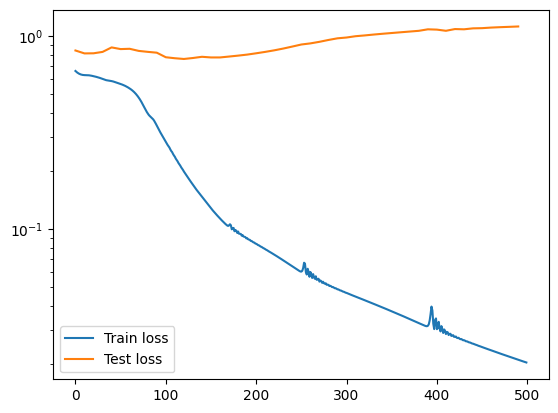

In [51]:
import matplotlib.pyplot as plt
plt.plot(np.arange(NUM_EPOCHS),train_losses,label='Train loss')
plt.plot(np.arange(0,NUM_EPOCHS,10),test_losses,label='Test loss')
plt.legend()
plt.yscale('log')